In [1]:
# Original simulation file without wavelength mask
SIM_FILE = '/datascope/subaru/user/swei20/data/bosz50000/z1/mag205_225_lowT_1M/train_200k_0/dataset.h5'

# Data used to train the networks
TRAINING_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0.npz'

# Wavelength mask used to train the networks
DENOISED_MASK = '/datascope/subaru/user/swei20/model/bosz50000_mask.npy'

# Blindspot denoised file
DENOISED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_N50000.npz'

# U-Net denoised file (trained on clean reference)
CLEANED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_E2_SUPERVISED_N50000.npz'

# DAE denoised file
# CLEANED_FILE = '/datascope/subaru/user/swei20/blindspot_rv/inputs/bosz50000_v3ep190/b1_l9_e48_k25_s1_bn1_d1_T0_S0_L0_snr3_b50000_rv500_ep5000_N50000_m0_v3ep190_DAE_N50000.npz'

N = 10000

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from collections import defaultdict
from tqdm.notebook import tqdm

In [3]:
plt.rcParams["text.usetex"] = True

# Load the simulation

In [4]:
# Load the pandas DataFrame from the HDF5 file stored in /dataset/params/table
with h5py.File(SIM_FILE, 'r') as f:
    params = pd.read_hdf(SIM_FILE, key='dataset/params')

params.shape

(200000, 35)

In [5]:
# # Select only those spectra that were interpolated in the log g direction
# data_mask = params['interp_param'] == PARAM

# Include all spectra
data_mask = np.full_like(params['interp_param'], True)

data_idx = np.where(data_mask)[0]
data_mask.sum()

200000

In [6]:
# Load the selected spectra from the HDF5 file
with h5py.File(SIM_FILE, 'r') as f:
    wave = f['spectrumdataset/wave'][:]
    flux = f['dataset/arrays/flux/value'][data_idx[:N], :]
    flux_err = f['dataset/arrays/error/value'][data_idx[:N], :]

wave.shape, flux.shape, flux_err.shape

((4096,), (10000, 4096), (10000, 4096))

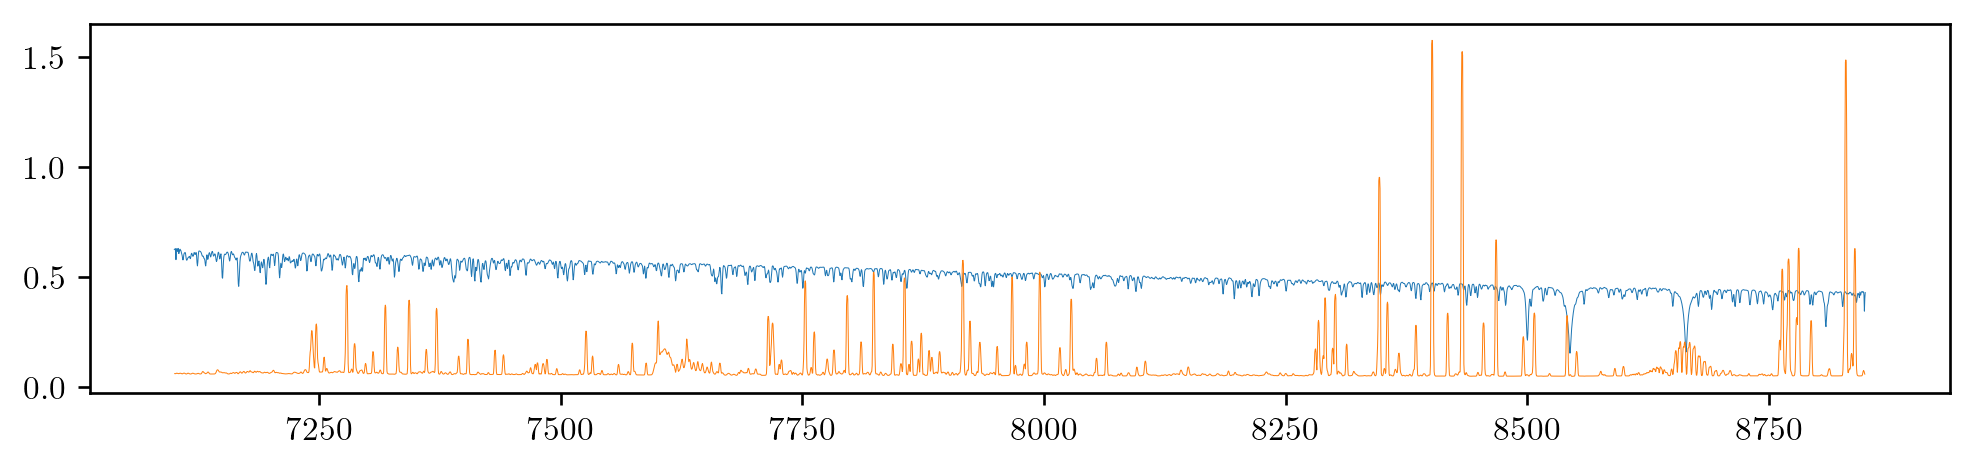

In [7]:
i = 0

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)
ax.plot(wave, flux[i, :], lw=0.3)
ax.plot(wave, flux_err[i, :], lw=0.3)

# Load the training set

In [8]:
with np.load(TRAINING_FILE) as npz:
    training = {k: npz[k].copy() for k in npz.files}

list(training.keys())

['nl',
 'flux',
 'noisy',
 'wave',
 'flux_err',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00']

In [9]:
training['wave'].shape, training['flux'].shape

((4096,), (50000, 4096))

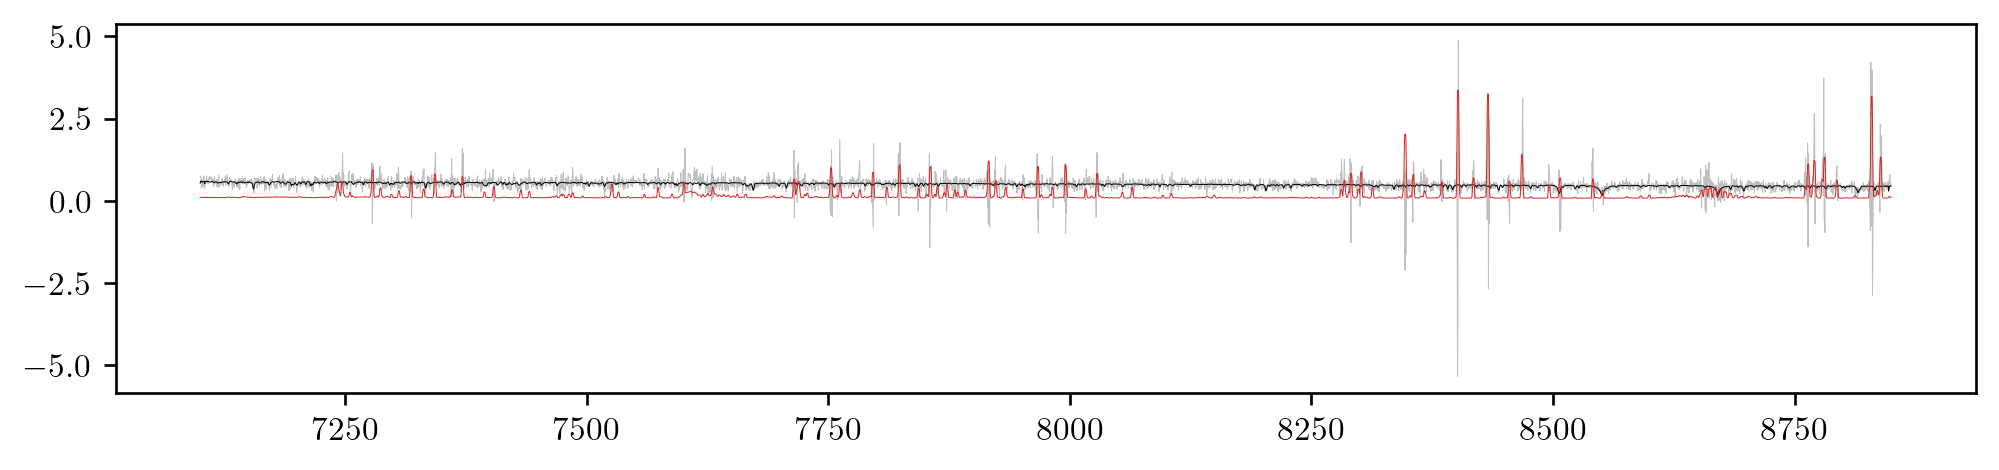

In [10]:
i = 0

w = training['wave']

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f = training['noisy'][i, :]
ax.plot(w, f, lw=0.3, c='gray', alpha=0.5)

f = training['flux'][i, :]
ax.plot(w, f, lw=0.3, c='k')

f = training['flux_err'][i, :]
ax.plot(w, f, lw=0.3, c='tab:red')

# Load the denoised data

In [11]:
wave_mask = np.load(DENOISED_MASK)
wave_mask.shape, wave_mask.sum()

((4096,), 3481)

In [12]:
with np.load(DENOISED_FILE) as npz:
    denoised = {k: npz[k].copy() for k in npz.files}

list(denoised.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'snr_denoised_db',
 'nl',
 'ckpt',
 'config',
 'mask_path',
 'source_npz']

In [13]:
denoised['wave'].shape, denoised['flux'].shape

((3481,), (50000, 3481))

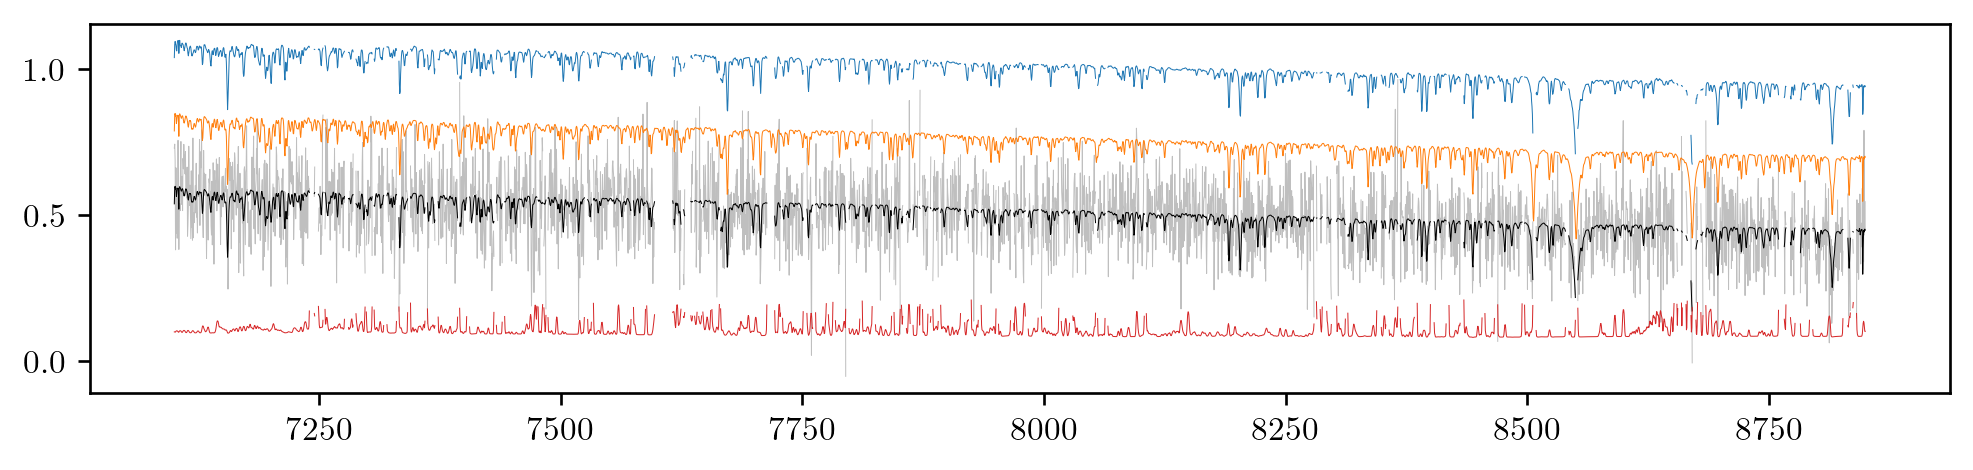

In [14]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = denoised['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = denoised['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

f = training['flux'][i, :]
ax.plot(wave, f + 0.25, lw=0.3, c='tab:orange')

# Load the clean-trained denoiser data

In [15]:
with np.load(CLEANED_FILE) as npz:
    cleaned = {k: npz[k].copy() for k in npz.files}

list(cleaned.keys())

['wave',
 'flux',
 'noisy',
 'flux_err',
 'denoised',
 'rv',
 'teff',
 'logg',
 'mh',
 'snr0',
 'snr00',
 'snr_noisy_db',
 'source_npz',
 'denoiser',
 'denoiser_ckpt',
 'config',
 'output_mode_used',
 'checkpoint_epoch',
 'checkpoint_metric',
 'N_subset',
 'wall_seconds',
 'rmse_noisy_mean',
 'rmse_denoised_mean',
 'snr_noisy_norm_mean',
 'snr_noisy_norm_median',
 'snr_denoised_norm_mean',
 'snr_denoised_norm_median']

In [16]:
cleaned['wave'].shape, cleaned['flux'].shape

((3481,), (50000, 3481))

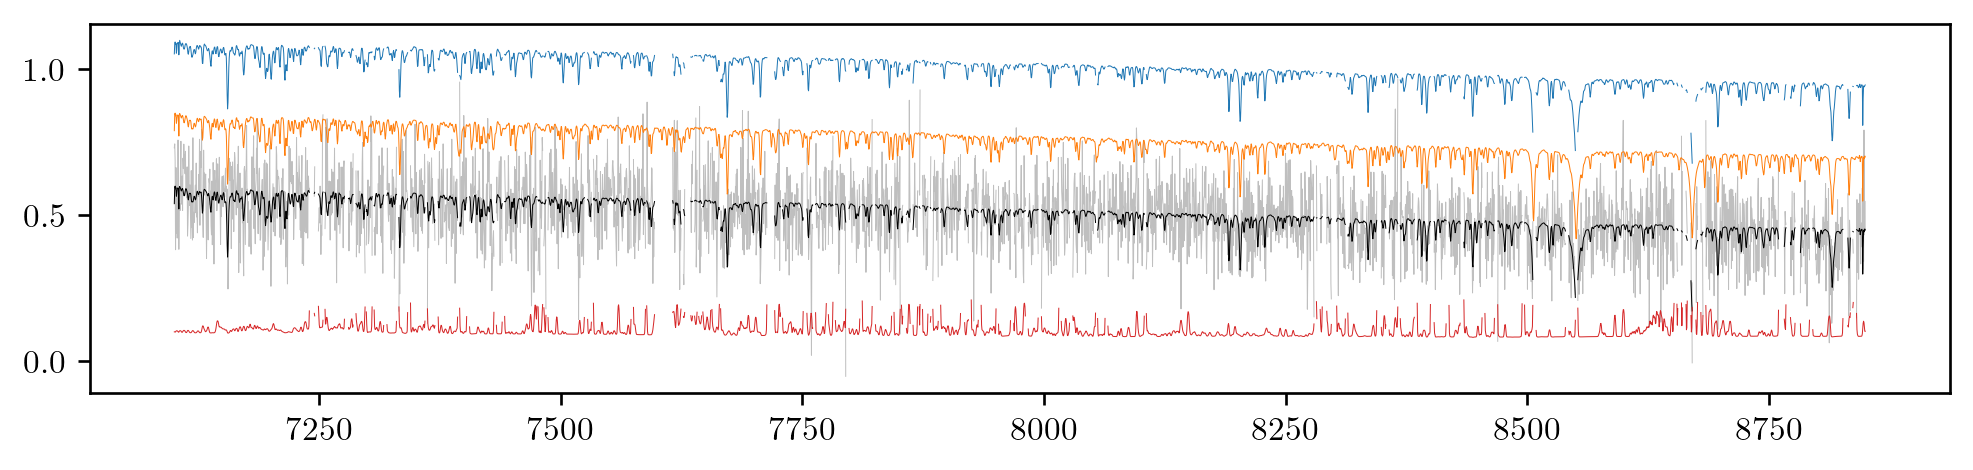

In [17]:
i = 0

w = wave
f = np.full_like(wave, np.nan)

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = cleaned['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

f[wave_mask] = cleaned['flux'][i, :]
ax.plot(wave, f, lw=0.3, c='k')

f[wave_mask] = cleaned['denoised'][i, :]
ax.plot(wave, f + 0.5, lw=0.3, c='tab:blue')

f[wave_mask] = cleaned['flux_err'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:red')

f = training['flux'][i, :]
ax.plot(wave, f + 0.25, lw=0.3, c='tab:orange')

# Compare the two denoisers

In [18]:
i = 20

w = wave
f = np.full_like(wave, np.nan)

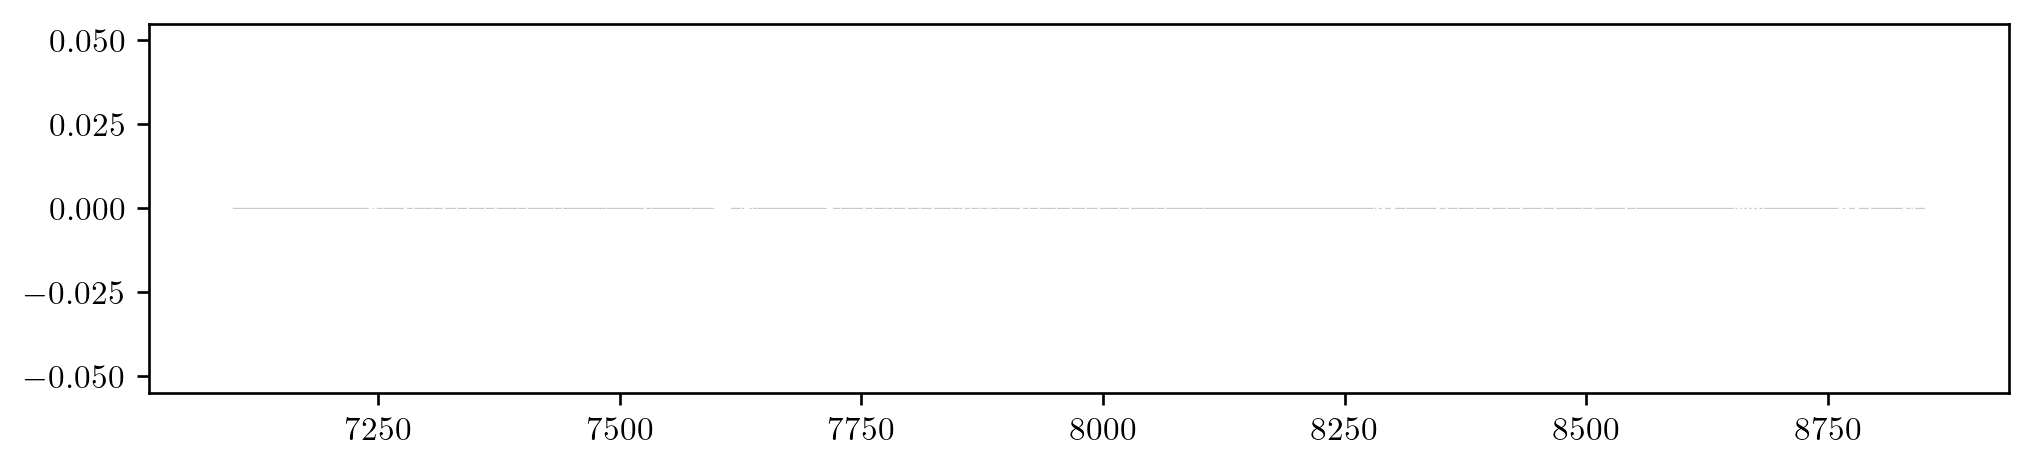

In [19]:
# Verify that doise realizations are the same

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['noisy'][i, :] - cleaned['noisy'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

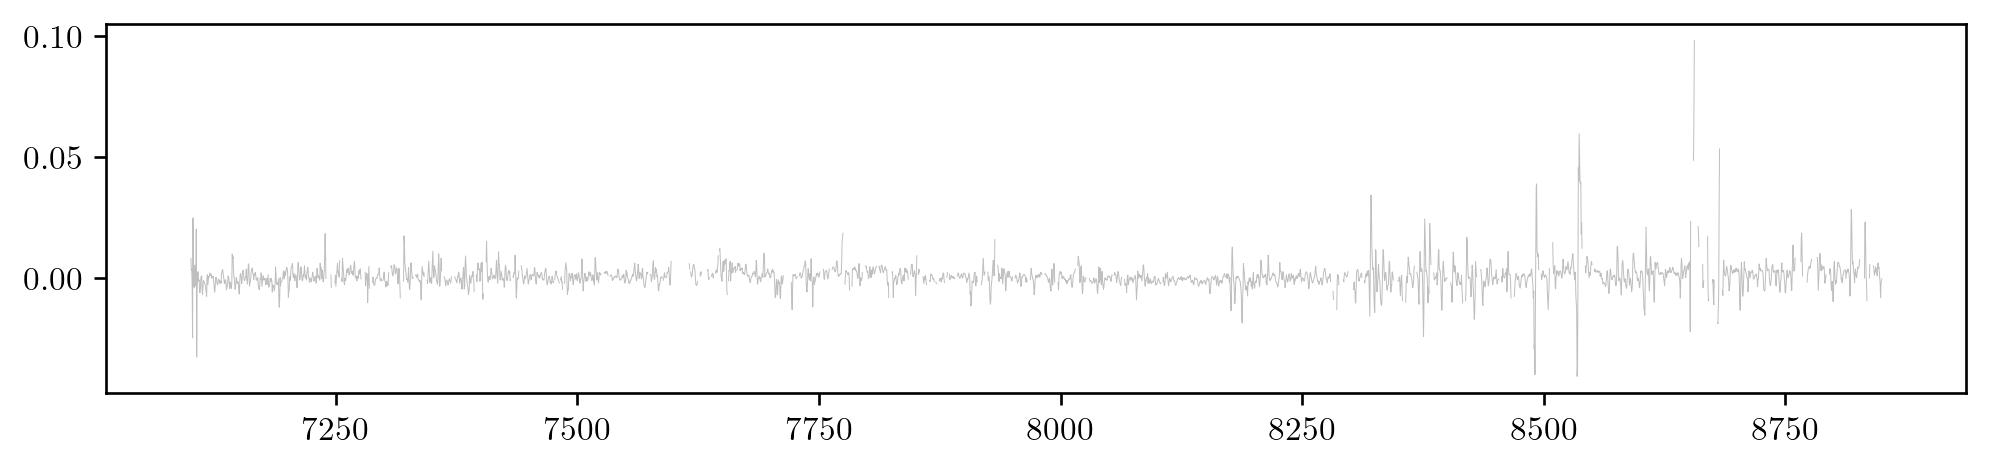

In [20]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['denoised'][i, :] - cleaned['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='gray', alpha=0.5)

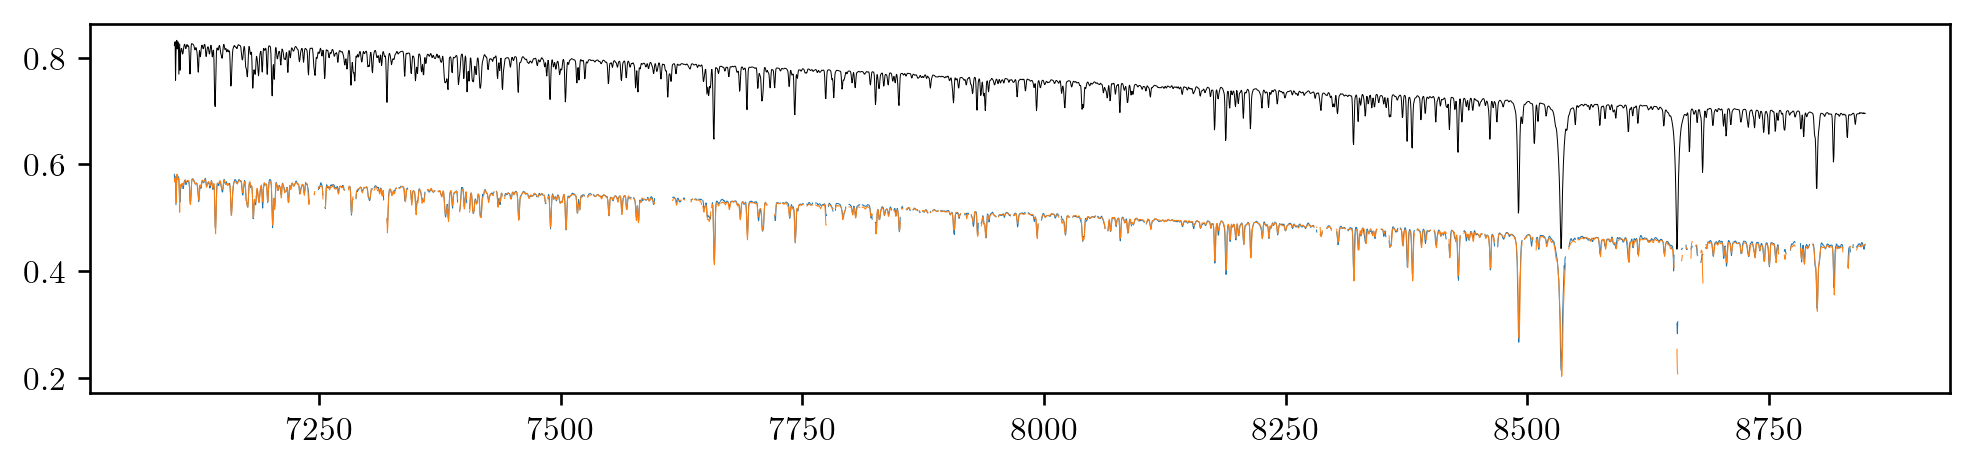

In [21]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

f[wave_mask] = cleaned['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:orange', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Run a PCA denoiser based on the clean spectra

In [22]:
from sklearn.decomposition import PCA

n_components = 16

pca = PCA(n_components=n_components, svd_solver="randomized", random_state=0)
coeff_pca = pca.fit_transform(denoised["flux"])   # shape: (n_spectra, n_components)
pca_basis = pca.components_                        # shape: (n_components, n_wavelength)

# Reconstruction
flux_pca_recon = pca.inverse_transform(coeff_pca)

print("coeff shape:", coeff_pca.shape)
print("basis shape:", pca_basis.shape)
print(f"explained variance ({n_components} comps):", pca.explained_variance_ratio_.sum())

coeff shape: (50000, 16)
basis shape: (16, 3481)
explained variance (16 comps): 0.92671967


In [23]:
flux_pca_recon.shape

(50000, 3481)

In [24]:
coeff_pca_noisy = pca.transform(denoised["noisy"])
flux_pca_noisy_recon = pca.inverse_transform(coeff_pca_noisy)

print("coeff shape:", coeff_pca_noisy.shape)
print("recon shape:", flux_pca_noisy_recon.shape)

coeff shape: (50000, 16)
recon shape: (50000, 3481)


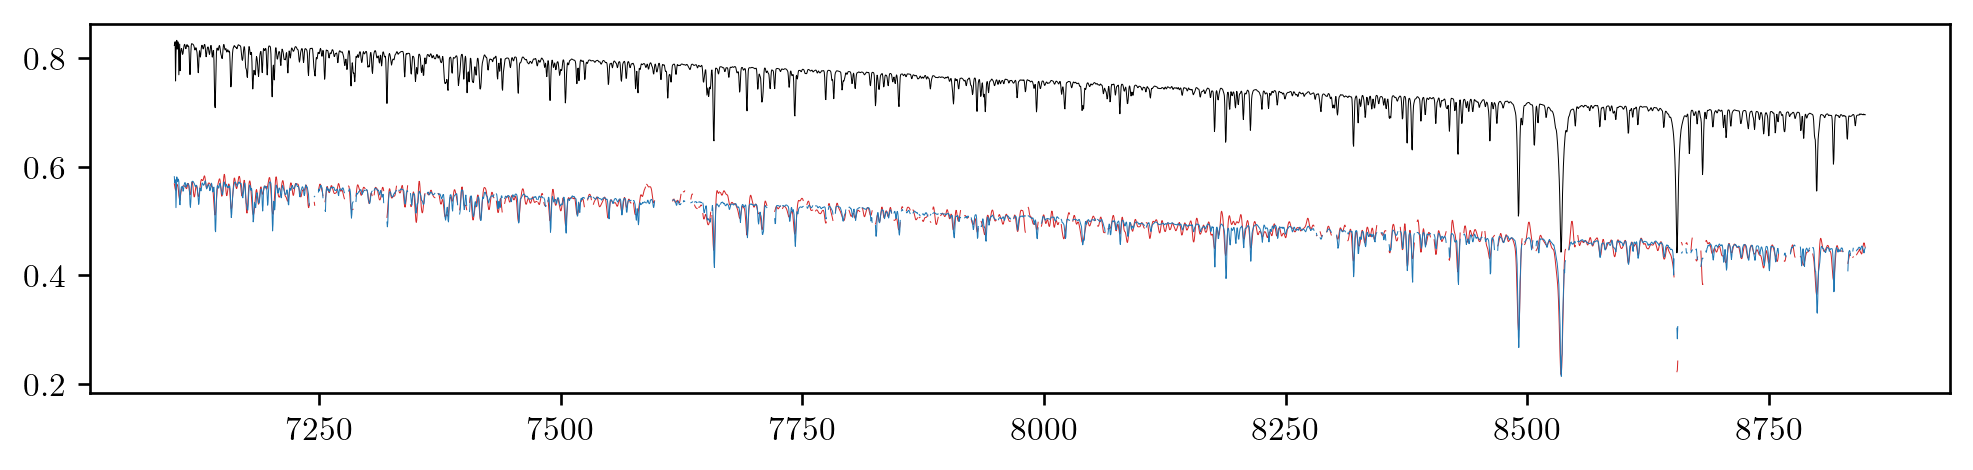

In [25]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = flux_pca_noisy_recon[i, :]
ax.plot(wave, f, lw=0.3, c='tab:red', alpha=1.0)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Calculate the S/N

/tmp/ipykernel_3776625/768908813.py:5: RuntimeWarning: divide by zero encountered in divide
  snr = (denoised['flux'] / denoised['flux_err'] * 2)
/tmp/ipykernel_3776625/768908813.py:5: RuntimeWarning: invalid value encountered in divide
  snr = (denoised['flux'] / denoised['flux_err'] * 2)


median SNR per resolution element: 13.95
mean SNR per resolution element: 15.89


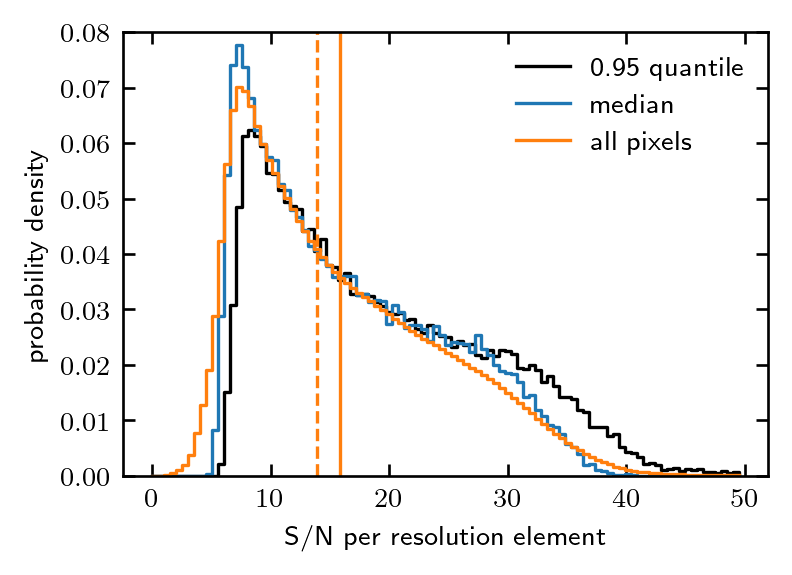

In [106]:
# Factor of 2 comes from width of the resolution element (2 pixels)

fig, ax = plt.subplots(figsize=(3.4, 2.5), dpi=240)

snr = (denoised['flux'] / denoised['flux_err'] * 2)
m = np.isfinite(snr)

bins = np.linspace(0, 50, 100)

x = np.nanquantile(snr, 0.95, axis=1)
hist, _ = np.histogram(x, bins=bins, density=True)
ax.step(bins[:-1], hist, where='post', lw=1, c='k', label='0.95 quantile')
# ax.plot(bins[:-1], hist, lw=1, c='k', label='0.95 quantile')

x = np.nanquantile(snr, 0.5, axis=1)
hist, _ = np.histogram(x, bins=bins, density=True)
ax.step(bins[:-1], hist, where='post', lw=1, c='tab:blue', label='median')
# ax.plot(bins[:-1], hist, lw=1, c='tab:blue', label='median')

x = snr[m].flatten()
hist, _ = np.histogram(x, bins=bins, density=True)
ax.step(bins[:-1], hist, where='post', lw=1, c='tab:orange', label='all pixels')
# ax.plot(bins[:-1], hist, lw=1, c='tab:orange', label='all pixels')

v = np.median(x)
print(f"median SNR per resolution element: {v:.2f}")
ax.axvline(v, color='tab:orange', linestyle='--', lw=1)

v = np.mean(x)
print(f"mean SNR per resolution element: {v:.2f}")
ax.axvline(v, color='tab:orange', linestyle='-', lw=1)

ax.set_xlabel(r'S/N per resolution element', fontsize=8)
ax.set_ylabel(r'probability density', fontsize=8)

ax.set_ylim(0, 0.08)

ax.legend(loc='upper right', fontsize=8, frameon=False)

ax.tick_params(axis='both', which='major', labelsize=8, direction='in', top=True, right=True)

fig.tight_layout()
fig.savefig('../figs/fig_snr_histogram.pdf', dpi=300)

# Denoise spectra using Savitzky-Golay

In [26]:
from scipy.signal import savgol_filter

# Apply Savitzky-Golay filter to denoise the noisy spectra
window_length = 11
polyorder = 1

flux_sg_recon = np.zeros_like(denoised['noisy'])
for idx in range(denoised['noisy'].shape[0]):
    flux_sg_recon[idx, :] = savgol_filter(denoised['noisy'][idx, :], window_length, polyorder)

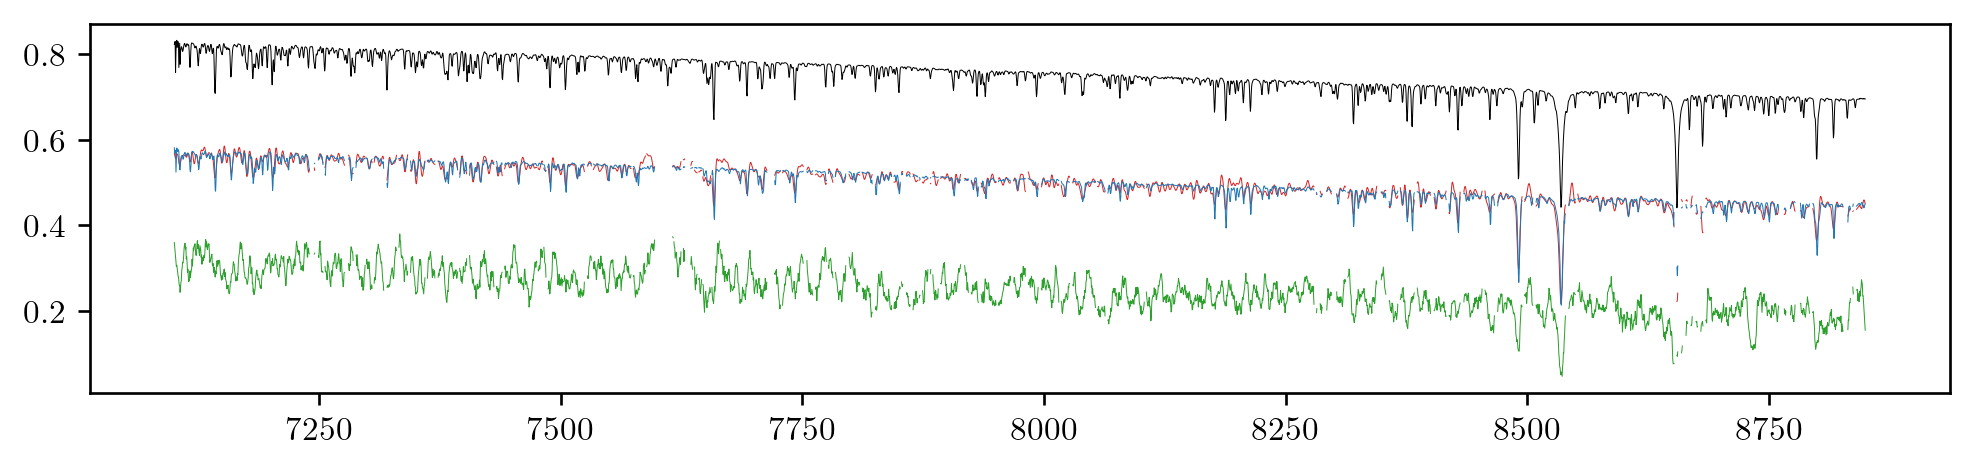

In [27]:
# Plot the difference between the denoised spectra

fig, ax = plt.subplots(figsize=(10, 2), dpi=240)

f[wave_mask] = flux_pca_noisy_recon[i, :]
ax.plot(wave, f, lw=0.3, c='tab:red', alpha=1.0)

f[wave_mask] = denoised['denoised'][i, :]
ax.plot(wave, f, lw=0.3, c='tab:blue', alpha=1.0)

f[wave_mask] = flux_sg_recon[i, :]
ax.plot(wave, f - 0.25, lw=0.3, c='tab:green', alpha=1.0)

ax.plot(training['wave'], training['flux'][i, :] + 0.25, lw=0.3, c='k', alpha=1.0)

# Calculate the RMSE

In [65]:
# Calculate the RMSE for blindspot and UNet

rmse_noisy = np.sqrt(np.nanmean((denoised['noisy'] - denoised['flux'])**2, axis=1))
rmse_blindspot = np.sqrt(np.nanmean((denoised['denoised'] - denoised['flux'])**2, axis=1))
rmse_unet = np.sqrt(np.nanmean((cleaned['denoised'] - cleaned['flux'])**2, axis=1))
rmse_pca = np.sqrt(np.nanmean((flux_pca_recon - denoised['flux'])**2, axis=1))
rmse_sg = np.sqrt(np.nanmean((flux_sg_recon - denoised['flux'])**2, axis=1))

r = (denoised['noisy'] - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_noisy = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_blindspot = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
m = np.isfinite(r)
rel_rmse_unet = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (flux_pca_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_pca = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

r = (flux_sg_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
rel_rmse_sg = np.sqrt(np.nanmean(np.where(m, r**2, np.nan), axis=1))

rmse_blindspot.shape, rmse_unet.shape, rmse_pca.shape, rmse_sg.shape

/tmp/ipykernel_3776625/767830524.py:9: RuntimeWarning: divide by zero encountered in divide
  r = (denoised['noisy'] - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3776625/767830524.py:13: RuntimeWarning: divide by zero encountered in divide
  r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3776625/767830524.py:17: RuntimeWarning: divide by zero encountered in divide
  r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
/tmp/ipykernel_3776625/767830524.py:21: RuntimeWarning: divide by zero encountered in divide
  r = (flux_pca_recon - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3776625/767830524.py:25: RuntimeWarning: divide by zero encountered in divide
  r = (flux_sg_recon - denoised['flux']) / denoised['flux']


((50000,), (50000,), (50000,), (50000,))

In [66]:
np.mean(rmse_blindspot), np.std(rmse_blindspot), np.mean(rmse_unet), np.std(rmse_unet)

(0.009793184, 0.008615655, 0.0096868435, 0.010720692)

In [67]:
np.mean(rel_rmse_blindspot), np.std(rel_rmse_blindspot), np.mean(rel_rmse_unet), np.std(rel_rmse_unet)

(0.025512496, 0.0418483, 0.025329921, 0.040109504)

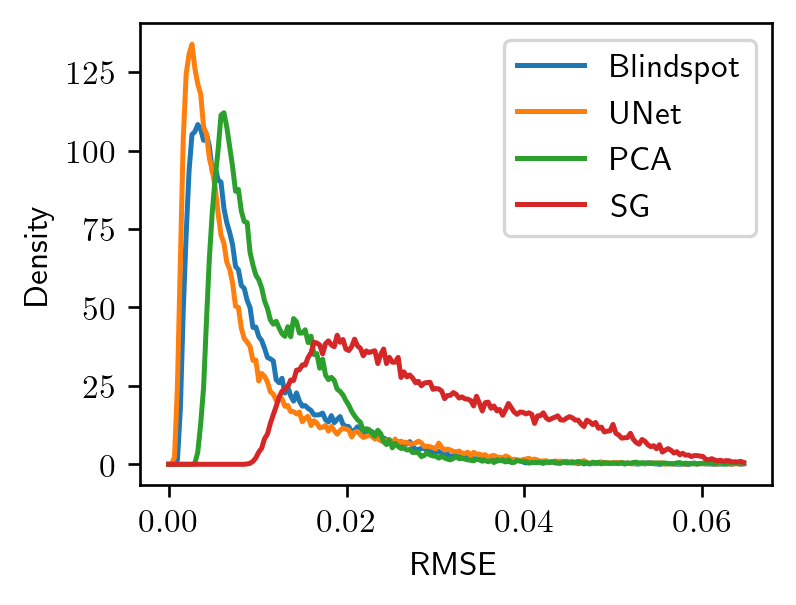

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(3.4, 2.5), dpi=240)

bins = np.linspace(0, 0.065, 200)

hist, _ = np.histogram(rmse_blindspot, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:blue', label='Blindspot')

hist, _ = np.histogram(rmse_unet, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:orange', label='UNet')

hist, _ = np.histogram(rmse_pca, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:green', label='PCA')

hist, _ = np.histogram(rmse_sg, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:red', label='SG')

ax.set_xlabel('RMSE')
ax.set_ylabel('Density')
ax.legend()
plt.show()

/tmp/ipykernel_3776625/3863165742.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


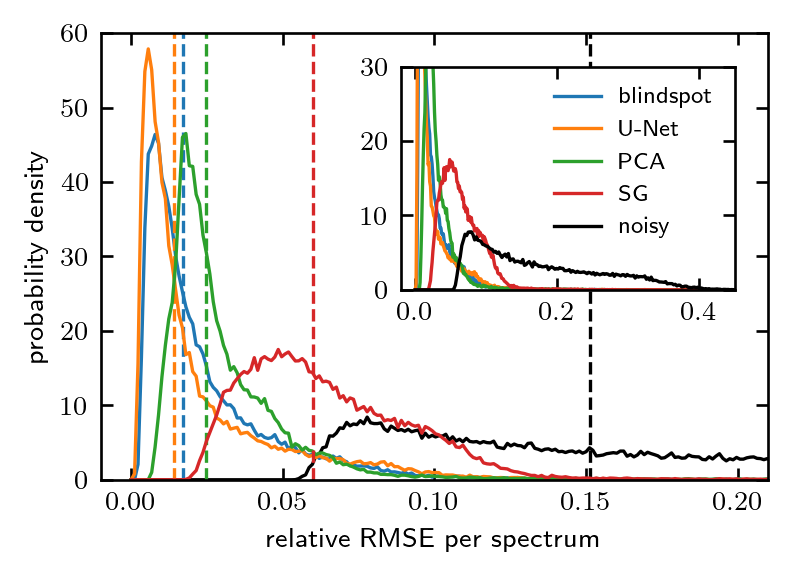

In [101]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots(1, 1, figsize=(3.4, 2.5), dpi=240)
ax_in = inset_axes(ax, width="50%", height="50%", loc="upper right", borderpad=1.0)

bins = np.linspace(0, 0.45, 400)

hist, _ = np.histogram(rel_rmse_noisy, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1, c='k', label='noisy')
ax.axvline(np.median(rel_rmse_noisy), color='k', linestyle='--', lw=1)

hist, _ = np.histogram(rel_rmse_blindspot, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1, c='tab:blue', label='blindspot')
ax.axvline(np.median(rel_rmse_blindspot), color='tab:blue', linestyle='--', lw=1)
ax_in.plot(bins[:-1], hist, lw=1, c='tab:blue', label='blindspot')

hist, _ = np.histogram(rel_rmse_unet, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1, c='tab:orange', label='U-Net')
ax.axvline(np.median(rel_rmse_unet), color='tab:orange', linestyle='--', lw=1)
ax_in.plot(bins[:-1], hist, lw=1, c='tab:orange', label='U-Net')

hist, _ = np.histogram(rel_rmse_pca, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1, c='tab:green', label='PCA')
ax.axvline(np.median(rel_rmse_pca), color='tab:green', linestyle='--', lw=1)
ax_in.plot(bins[:-1], hist, lw=1, c='tab:green', label='PCA')

hist, _ = np.histogram(rel_rmse_sg, bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1, c='tab:red', label='SG')
ax.axvline(np.median(rel_rmse_sg), color='tab:red', linestyle='--', lw=1)
ax_in.plot(bins[:-1], hist, lw=1, c='tab:red', label='SG')

ax.set_xlim(-0.01, 0.21)
ax.set_ylim(0, 60)
ax.set_xlabel('relative RMSE per spectrum', fontsize=8)
ax.set_ylabel('probability density', fontsize=8)

ax.tick_params(axis='both', which='major', labelsize=8, direction='in', top=True, right=True)

### ### ###

bins = np.linspace(0, 0.45, 200)

hist, _ = np.histogram(rel_rmse_noisy, bins=bins, density=True)
ax_in.plot(bins[:-1], hist, lw=1, c='k', label='noisy')

ax_in.set_xlim(-0.02, 0.45)
ax_in.set_ylim(0, 30)
ax_in.tick_params(axis='both', which='major', labelsize=8, direction='in', top=True, right=True)

ax_in.legend(loc='upper right', fontsize=7, frameon=False)

fig.tight_layout()
fig.savefig('../figs/fig_rmse_hist.pdf', dpi=300)

In [116]:
# Generate the latex table with the RMSE values

latex = Rf"""
\begin{{tabular}}{{llcccc}}
\hline
Denoising model & Training method & Mean          & Median        & $5$-percentile & $95$-percentile \\
                &                 & relative RMSE & relative RMSE & relative RMSE  & relativeRMSE \\
\hline
Noisy input & -- &
    {np.mean(rel_rmse_noisy):0.4f} &
    {np.median(rel_rmse_noisy):0.4f} &
    {np.percentile(rel_rmse_noisy, 5):0.4f} &
    {np.percentile(rel_rmse_noisy, 95):0.4f} \\
PCA, $k\!=\!16$ & clean input &
    {np.mean(rel_rmse_pca):0.4f} &
    {np.median(rel_rmse_pca):0.4f} &
    {np.percentile(rel_rmse_pca, 5):0.4f} &
    {np.percentile(rel_rmse_pca, 95):0.4f} \\
Savitzky-Golay filter & noisy input &
    {np.mean(rel_rmse_sg):0.4f} &
    {np.median(rel_rmse_sg):0.4f} &
    {np.percentile(rel_rmse_sg, 5):0.4f} &
    {np.percentile(rel_rmse_sg, 95):0.4f} \\
Blindspot & noisy reference, self-supervised &
    {np.mean(rel_rmse_blindspot):0.4f} &
    {np.median(rel_rmse_blindspot):0.4f} &
    {np.percentile(rel_rmse_blindspot, 5):0.4f} &
    {np.percentile(rel_rmse_blindspot, 95):0.4f} \\
Supervised U-Net & clean reference, supervised &
    {np.mean(rel_rmse_unet):0.4f} &
    {np.median(rel_rmse_unet):0.4f} &
    {np.percentile(rel_rmse_unet, 5):0.4f} &
    {np.percentile(rel_rmse_unet, 95):0.4f} \\
\hline
\end{{tabular}}
"""

print(latex)

# Save to .tex file
with open('../tab_rmse.tex', 'w') as f:
    f.write(latex)


\begin{tabular}{llcccc}
\hline
Denoising model & Training method & Mean          & Median        & $5$-percentile & $95$-percentile \\
                &                 & relative RMSE & relative RMSE & relative RMSE  & relativeRMSE \\
\hline
Noisy input & -- &
    0.1736 &
    0.1515 &
    0.0698 &
    0.3374 \\
PCA, $k\!=\!16$ & clean input &
    0.0319 &
    0.0248 &
    0.0123 &
    0.0684 \\
Savitzky-Golay filter & noisy input &
    0.0656 &
    0.0598 &
    0.0302 &
    0.1129 \\
Blindspot & noisy reference, self-supervised &
    0.0255 &
    0.0171 &
    0.0054 &
    0.0715 \\
Supervised U-Net & clean reference, supervised &
    0.0253 &
    0.0140 &
    0.0042 &
    0.0820 \\
\hline
\end{tabular}



/tmp/ipykernel_3776625/1068348908.py:5: RuntimeWarning: divide by zero encountered in divide
  r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3776625/1068348908.py:10: RuntimeWarning: divide by zero encountered in divide
  r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
/tmp/ipykernel_3776625/1068348908.py:15: RuntimeWarning: divide by zero encountered in divide
  r = (flux_pca_recon - denoised['flux']) / denoised['flux']
/tmp/ipykernel_3776625/1068348908.py:20: RuntimeWarning: divide by zero encountered in divide
  r = (flux_sg_recon - denoised['flux']) / denoised['flux']


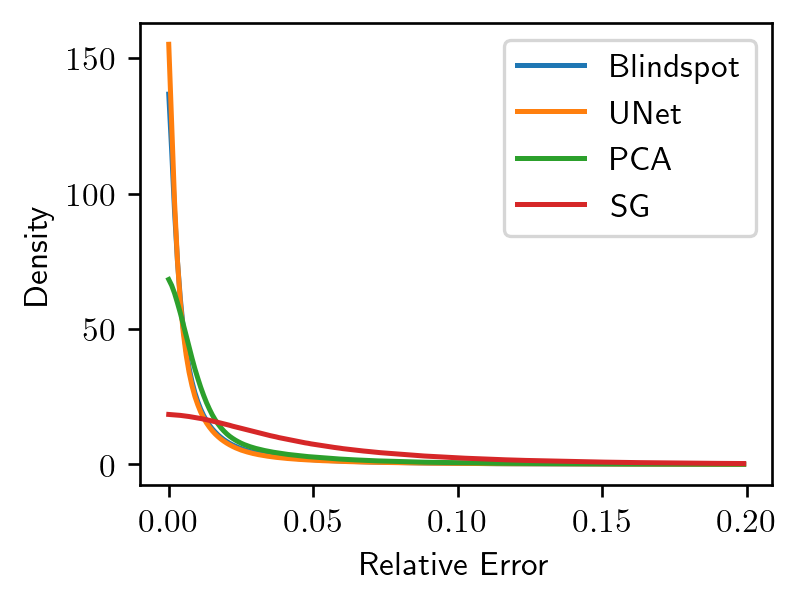

In [33]:
fig, ax = plt.subplots(1, 1, figsize=(3.4, 2.5), dpi=240)

bins = np.linspace(0, 0.2, 200)

r = (denoised['denoised'] - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
hist, _ = np.histogram(r[m].flatten(), bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:blue', label='Blindspot')

r = (cleaned['denoised'] - cleaned['flux']) / cleaned['flux']
m = np.isfinite(r)
hist, _ = np.histogram(r[m].flatten(), bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:orange', label='UNet')

r = (flux_pca_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
hist, _ = np.histogram(r[m].flatten(), bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:green', label='PCA')

r = (flux_sg_recon - denoised['flux']) / denoised['flux']
m = np.isfinite(r)
hist, _ = np.histogram(r[m].flatten(), bins=bins, density=True)
ax.plot(bins[:-1], hist, lw=1.5, c='tab:red', label='SG')

ax.set_xlabel('Relative Error')
ax.set_ylabel('Density')
ax.legend()
plt.show()

ax.set_yscale('log')
ax.set_ylabel('Density (log scale)')
plt.show()
